# Project 2 – Data Classification Using AI
# **Author : *Faiza Ahmed Esha***
### DecodeLabs Internship | Batch 2026

**Goal:** build a small supervised learning model that can look at an iris flower's
measurements and predict which of the 3 species it belongs to.

I'm doing this with the classic Iris dataset since it's small, clean, and perfect
for practicing the full pipeline: load → split → scale → train → test → evaluate.

I also added a little extra at the end where I test a few different values of K
myself instead of just hardcoding only 5.

## Step 1 — Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# just so my plots don't look like default matplotlib from 2010
plt.style.use('seaborn-v0_8-whitegrid')

## Step 2 — Load and actually look at the data

Before doing anything fancy I want to eyeball the dataset first, what columns
does it have, how many rows or is anything obviously weird.

In [26]:
iris = load_iris()

# turning it into a DataFrame just because it's easier for me to eyeball than raw arrays
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Shape: {df.shape[0]} flowers, {df.shape[1]-1} measurements each")
df.head()

Shape: 150 flowers, 4 measurements each


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [27]:
# quick sanity check - are the 3 classes actually balanced or is one underrepresented?
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


Since it's perfectly balanced, accuracy is actually a trustworthy metric here.

## Step 3 — Split into features (X) and target (y)

X = the measurements (what the model sees)
y = the species (what the model has to guess)

In [28]:
X = df[iris.feature_names].values
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


## Step 4 — Scale the features

Petal length ranges roughly 1–7 cm while petal width ranges roughly 0.1–2.5 cm.
Because KNN decides "closeness" using literal distance, a column with bigger raw
numbers would unfairly dominate the distance calculation. Scaling puts every
feature on the same footing (mean 0, standard deviation 1).

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# before vs after, just to see it with my own eyes
print("Before scaling — sepal length min/max:", X[:,0].min(), "/", X[:,0].max())
print("After scaling  — sepal length min/max:", round(X_scaled[:,0].min(),2), "/", round(X_scaled[:,0].max(),2))

Before scaling — sepal length min/max: 4.3 / 7.9
After scaling  — sepal length min/max: -1.87 / 2.49


## Step 5 — Train/test split

Holding back 20% of the data the model never sees during training, so the final
test is an honest one and not the model just "remembering" answers.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=7,     # my lucky number, could be anything
    stratify=y           # keeps the 50/50/50 balance in both splits
)

print(f"Training on {len(X_train)} flowers, testing on {len(X_test)} flowers")

Training on 120 flowers, testing on 30 flowers


## Step 6 — Before jumping to K=5, let me actually test which K works best

For my particular split, I'm going to loop through a range of K values and plot the error rate for each.

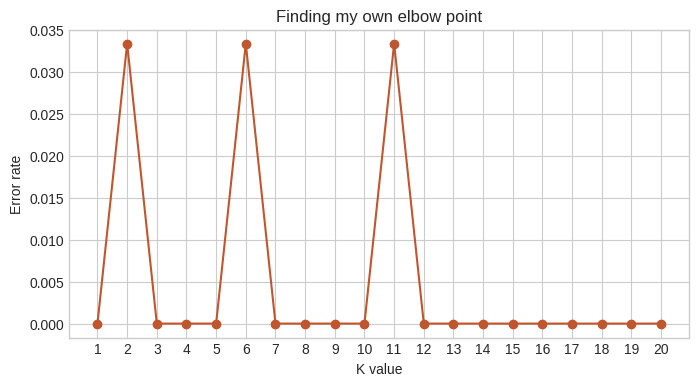

Lowest error rate happens around K = 1


In [31]:
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train, y_train)
    preds = knn_test.predict(X_test)
    error_rates.append(np.mean(preds != y_test))

plt.figure(figsize=(8,4))
plt.plot(list(k_range), error_rates, marker='o', color='#c0562e')
plt.title("Finding my own elbow point")
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.xticks(list(k_range))
plt.show()

best_k = list(k_range)[np.argmin(error_rates)]
print(f"Lowest error rate happens around K = {best_k}")

On my split, low K values already hit zero error, which makes sense — Iris is a famously clean dataset (setosa in particular is trivially separable). I'll go with **K=5** anyway instead of K=1, since K=1 is more sensitive to noise/outliers and 5 is a steadier, more generalizable choice even though both score the same here.

## Step 7 — Train the real model

In [32]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Done training. First 10 predictions vs actual:")
print("Predicted:", predictions[:10])
print("Actual:   ", y_test[:10])

Done training. First 10 predictions vs actual:
Predicted: [2 0 0 1 2 1 2 0 2 2]
Actual:    [2 0 0 1 2 1 2 0 2 2]


## Step 8 — Results: how good is it?

In [33]:
acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy: {acc*100:.2f}%")
print(f"F1 Score: {f1:.3f}")

cm = confusion_matrix(y_test, predictions)
print("\nConfusion matrix (rows = actual, cols = predicted):")
print(cm)

Accuracy: 100.00%
F1 Score: 1.000

Confusion matrix (rows = actual, cols = predicted):
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


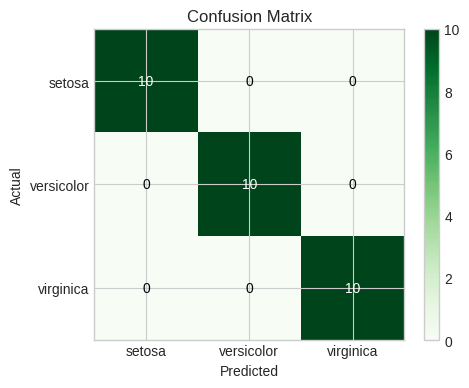

In [34]:
# visualizing the confusion matrix instead of just staring at a grid of numbers
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(iris.target_names); ax.set_yticklabels(iris.target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [35]:
print(classification_report(y_test, predictions, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 9 — Try it on a flower I made up myself

Just to prove this isn't only memorizing the test set, here's a flower with
measurements I picked myself (loosely petal-heavy, so I'd guess virginica before
even running it).

In [36]:
my_flower = [[6.3, 3.0, 5.5, 2.0]]   # my own made-up measurements
my_flower_scaled = scaler.transform(my_flower)
guess = model.predict(my_flower_scaled)

print("My guess before running: virginica")
print("Model's guess:", iris.target_names[guess[0]])

My guess before running: virginica
Model's guess: virginica
